# Lecture 6 – Python & GitHub II
## Demonstration Notebook

## 1. Environment Info

In [15]:
import sys, pandas as pd, numpy as np
print(sys.version)
pd.__version__

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


'3.0.1'

## 2. Imports & Config

In [16]:
import pandas as pd
import numpy as np
pd.set_option('display.float_format', '{:.4f}'.format)

## 3. Paths

In [17]:
DATA_PATH = '../assessment2_data/benchmarks/aus_eq_bm.csv'

## 4. Load & Sanity Checks

In [18]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date']).set_index('Date')
df.info()
df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 120 entries, 2016-01-31 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Return  120 non-null    float64
dtypes: float64(1)
memory usage: 1.9 KB


,Return
Date,
2016-01-31,-0.0249
2016-02-29,0.0414
2016-03-31,0.0333
2016-04-30,0.0241
2016-05-31,-0.0270


## 5. Transformations

In [19]:
# Example transformation: monthly alignment
df = df.sort_index().asfreq('ME')
df.head()

,Return
Date,
2016-01-31,-0.0249
2016-02-29,0.0414
2016-03-31,0.0333
2016-04-30,0.0241
2016-05-31,-0.0270


## 6. Sample Metric Functions

In [20]:
def annualised_return(r):
    return (1 + r).prod() ** (12/len(r)) - 1

def annualised_vol(r):
    return r.std() * np.sqrt(12)

## 7. Visual Checks

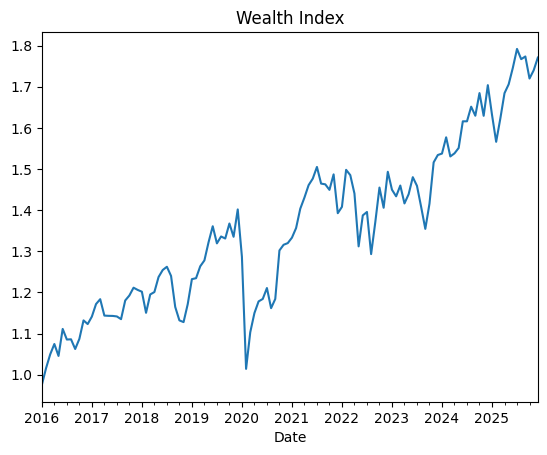

In [21]:
import matplotlib.pyplot as plt
((1+df['Return']).cumprod()).plot(title='Wealth Index'); plt.show()

## 8. Summary

In [22]:
print('Ann Return:', annualised_return(df['Return']))
print('Ann Vol:', annualised_vol(df['Return']))

Ann Return: 0.05881129371129035
Ann Vol: 0.13528078956455747
